/Users/yerik/_apple_lib/_b_envs/2ms_env/lib/python3.11/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


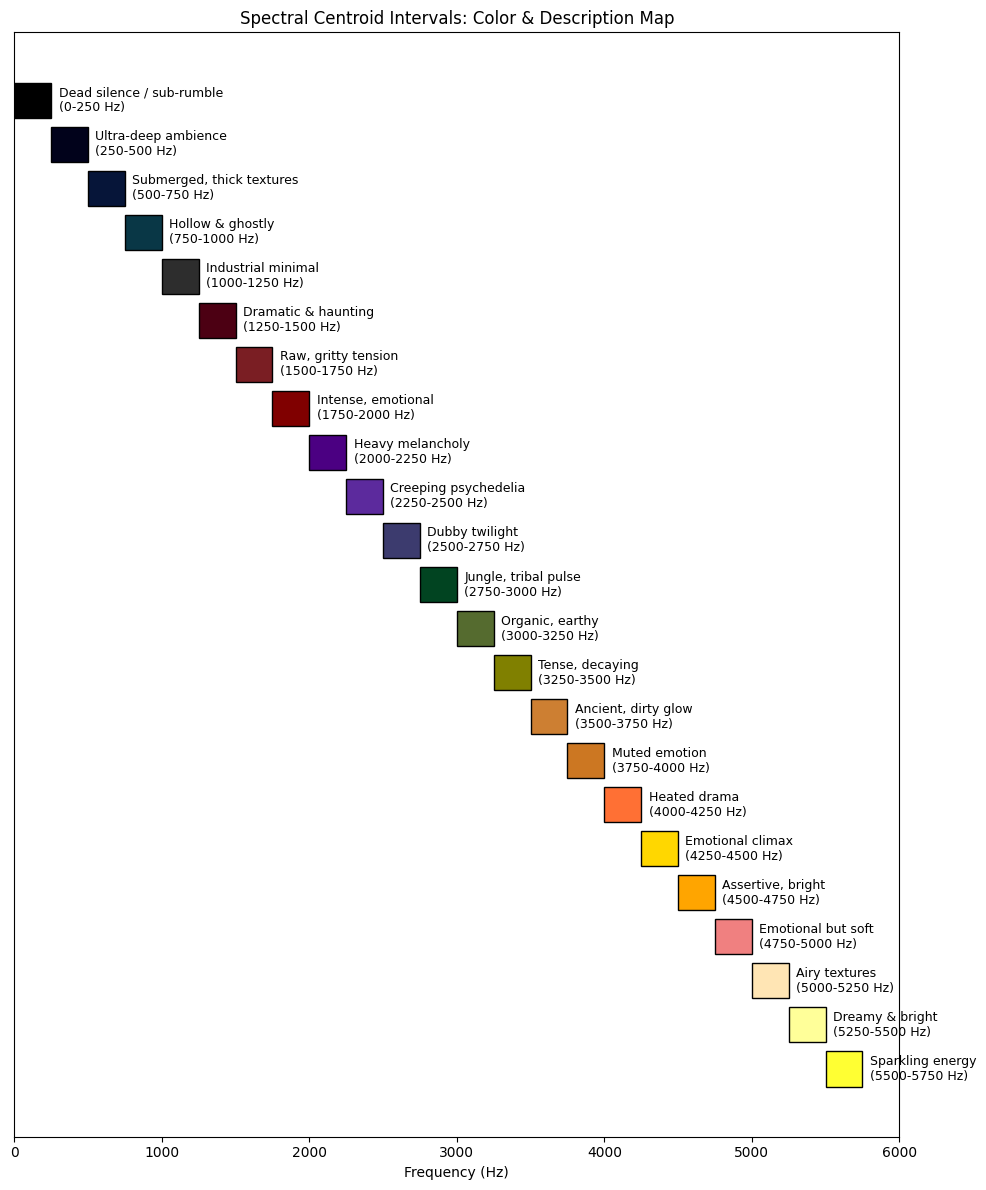

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define the intervals and their colors and descriptions
spectral_centroid_intervals_1504 = [
    (0, 250, '#000000', 'Dead silence / sub-rumble'),
    (250, 500, '#01021B', 'Ultra-deep ambience'),
    (500, 750, '#061539', 'Submerged, thick textures'),
    (750, 1000, '#093746', 'Hollow & ghostly'),
    (1000, 1250, '#2D2D2D', 'Industrial minimal'),
    (1250, 1500, '#4C0013', 'Dramatic & haunting'),
    (1500, 1750, '#7A1E23', 'Raw, gritty tension'),
    (1750, 2000, '#800000', 'Intense, emotional'),
    (2000, 2250, '#4B0082', 'Heavy melancholy'),
    (2250, 2500, '#5C2A9D', 'Creeping psychedelia'),
    (2500, 2750, '#3C3B6E', 'Dubby twilight'),
    (2750, 3000, '#014421', 'Jungle, tribal pulse'),
    (3000, 3250, '#556B2F', 'Organic, earthy'),
    (3250, 3500, '#808000', 'Tense, decaying'),
    (3500, 3750, '#CD7F32', 'Ancient, dirty glow'),
    (3750, 4000, '#CC7722', 'Muted emotion'),
    (4000, 4250, '#FF7034', 'Heated drama'),
    (4250, 4500, '#FFD700', 'Emotional climax'),
    (4500, 4750, '#FFA500', 'Assertive, bright'),
    (4750, 5000, '#F08080', 'Emotional but soft'),
    (5000, 5250, '#FFE5B4', 'Airy textures'),
    (5250, 5500, '#FFFF99', 'Dreamy & bright'),
    (5500, 5750, '#FFFF33', 'Sparkling energy'),
    (5750, float('inf'), '#FFFFFF', 'Harsh, clinical, hyper-bright')
]

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 12))
y_pos = range(len(spectral_centroid_intervals_1504))

# Plot colored bars
for i, (start, end, color, label) in enumerate(spectral_centroid_intervals_1504):
    ax.barh(i, end - start, left=start, color=color, edgecolor='black')
    ax.text(end + 50, i, f'{label}\n({start}-{int(end) if end != float("inf") else "∞"} Hz)',
            va='center', fontsize=9)

# Styling
ax.set_yticks([])
ax.set_xlabel('Frequency (Hz)')
ax.set_title('Spectral Centroid Intervals: Color & Description Map')
ax.set_xlim(0, 6000)
ax.invert_yaxis()
plt.tight_layout()

plt.show()


In [15]:
# -----######-----###### PADDED CLEAN IMPORTER -----######-----######
import pandas as pd
import chardet

def _read_2304_musiclib_GET_df_clean(path_txt):
    """
    Reads a tab-separated music metadata TXT file with auto encoding detection.
    Automatically handles mismatched column counts by padding or truncating rows.
    
    Parameters:
        path_txt: Full path to the .txt file
    
    Returns:
        pd.DataFrame: Cleaned DataFrame with correct column headers
    """
    # Detect encoding
    with open(path_txt, 'rb') as f:
        raw_data = f.read()
        result = chardet.detect(raw_data)
        encoding = result['encoding']

    # Decode using detected encoding
    decoded = raw_data.decode(encoding).splitlines()

    # Parse header
    header_line = decoded[0].lstrip('#').strip()
    headers = [h.strip() for h in header_line.split('\t')]
    n_cols = len(headers)

    # Build padded rows
    rows = []
    for line in decoded[1:]:
        cols = line.strip().split('\t')
        if len(cols) < n_cols:
            cols.extend([''] * (n_cols - len(cols)))  # pad
        elif len(cols) > n_cols:
            cols = cols[:n_cols]  # truncate
        rows.append(cols)

    df = pd.DataFrame(rows, columns=headers)
    return df


In [16]:
# Replace with your actual path
file_path = "/Users/yerik/Downloads/arch.txt"

df_music = _read_2304_musiclib_GET_df_clean(file_path)

# Quick preview
df_music.head(3)


,File Type,Bitrate,BPM,Key,Track Title,Artist,Artwork,Genre,Label,Remixer,Release Date,Year,Location,Rating,File Name,Comments,Album,Bitdepth,Time,Date Added
0,1,MP3,320 kbps,160.00,8A,GASOLINE (Original Mix),"HiTech, Juan Michael OG",,Electronica,Loma Vista Recordings,,2024-07-26,2024,/Users/yerik/Music/_0_OLD_SOURCE/_rk_music_31/...,,"GASOLINE-BY-HiTech,_Juan_Michael_OG_(Origina.mp3",,GASOLINE,16,02:48
1,2,AIFF,1411 kbps,130.00,2A,Dirty Games (Girl Unit Remix),Lektor Scopes,,Bass / Club,Night Slugs,,2023-06-14,2023,/Users/yerik/Music/_0_OLD_SOURCE/_rk_music_34/...,*****,Dirty_Games-BY-Lektor_Scopes_(Girl_Unit_Remix)...,o,Night Slugs Classix Remixed,16,04:03
2,3,WAV,1411 kbps,130.00,12A,Ha Dub(2PeKes Vogue Remix),2PeKes,,,,,,0,/Users/yerik/Music/_0_OLD_SOURCE/_rk_music_35/...,,b9AOl-8_4Bpm_131_0Key_8B_5cnt-rnk_8B3B8B-123oc...,,,16,03:34


In [17]:
len(df_music)

7110

In [2]:
# -----######-----###### SUB FUNCTION: Downsize AIFF + Replace Original -----######-----######
def downsize_aiff(file_path, target_sample_rate, target_bit_depth):
    """
    Downsizes a single AIFF file, writes new version with metadata, deletes original.
    """
    try:
        audio = AudioSegment.from_file(file_path, format="aiff")
        downsized_audio = audio.set_frame_rate(target_sample_rate).set_sample_width(target_bit_depth // 8)

        # Preserve metadata
        original_metadata = mutagen.File(file_path)
        temp_output_path = file_path + ".temp.aiff"

        # Export downsized audio
        downsized_audio.export(temp_output_path, format="aiff")

        # Restore metadata to temp file
        downsized_file = AIFF(temp_output_path)
        for key, value in original_metadata.items():
            downsized_file[key] = value
        downsized_file.save()

        # Replace original file
        os.remove(file_path)
        os.rename(temp_output_path, file_path)

        print(f"✅ Downsized and replaced: {os.path.basename(file_path)}")
    except Exception as e:
        print(f"❌ Error downsizing {file_path}: {e}")

import os
from pydub import AudioSegment
from pydub.utils import mediainfo
import pandas as pd
import mutagen
from mutagen.aiff import AIFF

# -----######-----###### MAIN FUNCTION: Analyze & Prompt Downsize -----######-----######
def analyze_and_prompt_downsize_aiff(folder_path, target_sample_rate=44100, target_bit_depth=16):
    """
    Scans for .aiff files, reports those needing downsizing. Prompts user before processing.
    """
    to_downsize = []
    all_stats = []

    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(".aiff"):
                file_path = os.path.join(root, file)
                try:
                    info = mediainfo(file_path)
                    sample_rate = int(info.get('sample_rate', 0))
                    bit_depth = int(info.get('bits_per_sample', 0))
                    all_stats.append((file_path, sample_rate, bit_depth))

                    if sample_rate != target_sample_rate or bit_depth != target_bit_depth:
                        to_downsize.append((file_path, sample_rate, bit_depth))

                except Exception as e:
                    print(f"❌ Error reading {file_path}: {e}")

    # Show all detected mismatches
    print("\n🔍 Files that need downsizing:")
    for i, (fp, sr, bd) in enumerate(to_downsize, 1):
        print(f"{i:02d}. {os.path.basename(fp)} — SR: {sr}, Bit: {bd}")

    print(f"\n📊 Total AIFF files: {len(all_stats)}")
    print(f"⚠️ Files requiring downsizing: {len(to_downsize)}")

    if to_downsize:
        proceed = input("\n👉 Proceed with downsizing and replacing originals? (y/n): ").strip().lower()
        if proceed == 'y':
            for file_path, _, _ in to_downsize:
                downsize_aiff(file_path, target_sample_rate, target_bit_depth)
        else:
            print("⛔ Cancelled by user.")
    else:
        print("✅ All files already match target specs.")

analyze_and_prompt_downsize_aiff("/Volumes/MUSIC_PROD/STEMS_24_years/vocals")


🔍 Files that need downsizing:
01. SIL010___1069_1aBATCH__Organize IDK_IN THE SUN FINAL 88.2 kHz_vocals.aiff — SR: 44100, Bit: 24
02. SIL010___1071_1aBATCH__Organize IDK_JOURNEY WITHIN FINAL 88.2kHz_vocals.aiff — SR: 44100, Bit: 24
03. SIL010___1074_1aBATCH__Organize IDK_RUNNIN FINAL 88.2kHz_vocals.aiff — SR: 44100, Bit: 24
04. SIL010___1076_1aBATCH__Organize IDK_SUPERPOWERS FINAL 88.2 kHz_vocals.aiff — SR: 44100, Bit: 24
05. SIL010___1131_1aBATCH__m3u8_Music_rk_purged_Odyssey - Going Back to My Roots (12_ Versio_2_0_vocals.aiff — SR: 44100, Bit: 24
06. SIL010___1199_1aBATCH__to_erase_UNWANTED_Lizwi, THEMBA (SA) - Mountain High feat. -1_5_1_vocals.aiff — SR: 44100, Bit: 24
07. SIL010___1209_1aBATCH__to_erase_UNWANTED_VLTRA (IT) - Funky Walking (Original Mix)_2_0_vocals.aiff — SR: 44100, Bit: 24
08. SIL010___1224_1aBATCH_after_dupl_surprise_001_&ME, Rampa, Adam Port, Keinemusik, Nomi Ruiz_2_0_vocals.aiff — SR: 44100, Bit: 24
09. SIL010___1243_1aBATCH_after_dupl_surprise_004_2-JT_Donalds


👉 Proceed with downsizing and replacing originals? (y/n):  y


✅ Downsized and replaced: SIL010___1069_1aBATCH__Organize IDK_IN THE SUN FINAL 88.2 kHz_vocals.aiff
✅ Downsized and replaced: SIL010___1071_1aBATCH__Organize IDK_JOURNEY WITHIN FINAL 88.2kHz_vocals.aiff
✅ Downsized and replaced: SIL010___1074_1aBATCH__Organize IDK_RUNNIN FINAL 88.2kHz_vocals.aiff
✅ Downsized and replaced: SIL010___1076_1aBATCH__Organize IDK_SUPERPOWERS FINAL 88.2 kHz_vocals.aiff
✅ Downsized and replaced: SIL010___1131_1aBATCH__m3u8_Music_rk_purged_Odyssey - Going Back to My Roots (12_ Versio_2_0_vocals.aiff
✅ Downsized and replaced: SIL010___1199_1aBATCH__to_erase_UNWANTED_Lizwi, THEMBA (SA) - Mountain High feat. -1_5_1_vocals.aiff
✅ Downsized and replaced: SIL010___1209_1aBATCH__to_erase_UNWANTED_VLTRA (IT) - Funky Walking (Original Mix)_2_0_vocals.aiff
✅ Downsized and replaced: SIL010___1224_1aBATCH_after_dupl_surprise_001_&ME, Rampa, Adam Port, Keinemusik, Nomi Ruiz_2_0_vocals.aiff
✅ Downsized and replaced: SIL010___1243_1aBATCH_after_dupl_surprise_004_2-JT_Donaldso

KeyboardInterrupt: 

In [ ]:
analyze_and_prompt_downsize_aiff("/Volumes/MUSIC_PROD/STEMS_24_years/_2023_STEMS_AIFF")

In [ ]:
analyze_and_prompt_downsize_aiff("/Volumes/MUSIC_PROD/STEMS_24_years/_2024_STEMS_AIFF")

In [ ]:
analyze_and_prompt_downsize_aiff("/Volumes/MUSIC_PROD/STEMS_24_years/_othreSRC_STEM_AIFF")